## TF-IDF Vectorization
The Scikit-learn's TfidfVectorizer was fit on the corpus of job skill documents. Each job posting becomes a vector where each dimension represents a skill token, weighted by how frequently it appears in that posting relative to how commonly it appears across all postings. Less common but relevant skills receive higher weights, while more common skills like python are down-weighted, giving the model a more nuanced sense of what makes each job distinct.
Recommendation Engine
When a user inputs their skills and experience level, their input is transformed into the same TF-IDF vector space using the already-fitted vectorizer. Cosine similarity is then computed between the user vector and every job posting vector, measuring the angular distance between them. A score of 1 being a perfect match and 0 being no overlap. Results are filtered by experience level and the top-N most similar jobs are returned, ranked by similarity score.

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from sklearn.feature_extraction.text import TfidfVectorizer


# Loading dataset
df = pd.read_csv("Tech_Market_CleanSkills.csv")


# Removing missign or 'unknown' skills
df = df[df["skills"].notna()]
df = df[df["skills"] != "unknown"]

# Splitting skills into a list
df["skills_list"] = df["skills"].apply(lambda x: x.split(","))

# Frequency analysis
all_skills = [skill for sublist in df["skills_list"] for skill in sublist]

# Count frequency
skill_counts = pd.Series(all_skills).value_counts()

# Get unique skills
unique_skills = set(all_skills)
print("Total unique skills:", len(unique_skills))
print(sorted(unique_skills))

# Top N skills
top_n = 5
top_skills = skill_counts.head(top_n)

print("Top Skills:\n", top_skills)


Total unique skills: 2513
[' .NET', ' 1099', ' 3D', ' 3D Animation', ' 3D Design', ' 3D Graphics', ' 3D Modeling', ' 3D Printing', ' 3D Reconstruction', ' 3D Rendering', ' 3D Visualization', ' 5D Scene Reconstruction', ' 6G', ' A/B Testing', ' AEC Industry', ' AI', ' AI Agents', ' AI Applications', ' AI Assistant', ' AI Infrastructure', ' AI Integration', ' AI Models', ' AI Platform', ' AI Products', ' AI Research', ' AI Science', ' AI Search', ' AI Security', ' AI Solutions', ' AI Technologies', ' AI Technology', ' AI Testing', ' AI Tools', ' AI integration', ' AI security', ' AI-driven Collection', ' AI-driven Development', ' AI/LLM', ' AI/ML', ' AI/ML Engineering', ' APAC', ' API', ' API Design', ' API Development', ' API Documentation', ' API Integration', ' API Integrations', ' API Security', ' API integration', ' APIs', ' AR', ' AR/VR', ' ASP.NET', ' ATS', ' AWS', ' AWS Bedrock', ' AWS/Azure/GCP', ' Academic Collaboration', ' Accel Backed', ' Accelerators', ' Access Control', ' A

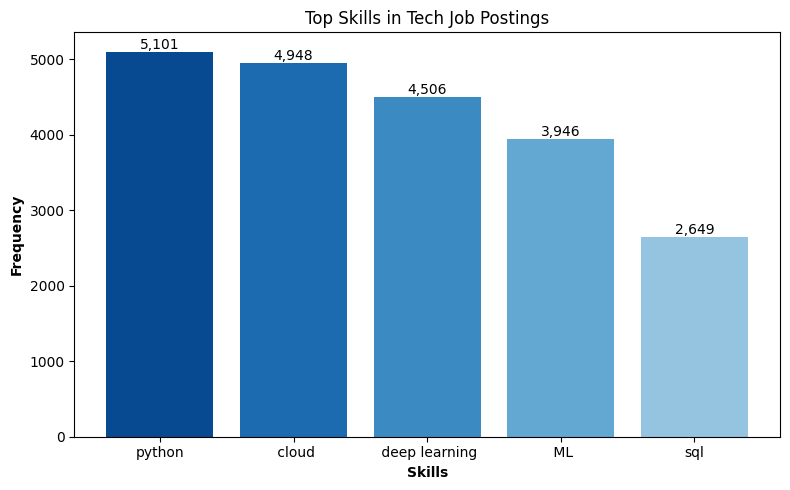

In [2]:
# Visualization
top_n = 5
top_skills = skill_counts.head(top_n)

plt.figure(figsize=(8,5))

# Create gradient colors
colors = cm.Blues(np.linspace(0.9, 0.4, len(top_skills)))

bars = plt.bar(top_skills.index, top_skills.values, color=colors)

# Add labels above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha='center',
        va='bottom'
    )

plt.xlabel("Skills", fontweight='bold')
plt.ylabel("Frequency", fontweight='bold')
plt.title("Top Skills in Tech Job Postings")

plt.tight_layout()
plt.show()

In [3]:
# TF-IDF for recommendation system
df["skills_text"] = df["skills_list"].apply(lambda x: " ".join(x))

tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(df["skills_text"])

print("\nTF-IDF Matrix Shape:", tfidf_matrix.shape)


TF-IDF Matrix Shape: (11099, 1487)


# Parameters:
    user_skills: list of str (e.g. ["python", "sql", "machine learning"])
    user_experience: str (e.g. "mid", "senior", "entry")
    top_n: int (number of recommendations to return)

In [10]:
from sklearn.metrics.pairwise import cosine_similarity

def get_recommendations(user_skills, user_experience, top_n=5):

    # usse the fitted TF-IDF to build build user profile vector
    user_skills_text = " ".join(user_skills)
    user_vector = tfidf.transform([user_skills_text])

    # computer cosine similarity between user profile and all job posts
    similarities = cosine_similarity(user_vector, tfidf_matrix).flatten()

    # filter by experience level ----- lower it for  case-insensitive
    experience_mask = df["experience"].str.lower() == user_experience.lower()

    # apply the similarity scores only to matching experience rows
    filtered_scores = similarities.copy()
    filtered_scores[~experience_mask] = -1  # exclude non-matching experience

    # get top-N indices
    top_indices = filtered_scores.argsort()[::-1][:top_n]

    # return the results dataframe
    results = df.iloc[top_indices][["job_title", "skills", "experience", "salary"]].copy()
    results["similarity_score"] = similarities[top_indices].round(4)
    results = results.reset_index(drop=True)
    results.index += 1  # start ranking at 1

    return results

#  Put in skills

In [12]:
user_skills = input("Enter your skills (separate by comma): ").split(",")
user_skills = [skill.strip() for skill in user_skills]
user_experience = input("Enter your experience level (entry/mid/senior): ").strip().lower()

recommendations = get_recommendations(user_skills, user_experience, top_n=5)
print(recommendations.to_string())


# try:"python", "machine learning", "sql"

Enter your skills (separate by comma): "python", "machine learning", "sql"
Enter your experience level (entry/mid/senior): entry
       job_title                      skills experience    salary  similarity_score
1  Data Engineer  python, sql, deep learning      Entry   86645.0            0.4352
2    AI Engineer  python, sql, deep learning      Entry  105808.0            0.4352
3    AI Engineer  python, sql, deep learning      Entry  101007.0            0.4352
4    AI Engineer  python, sql, deep learning      Entry  105552.0            0.4352
5    AI Engineer  python, sql, deep learning      Entry  123569.0            0.4352
